# 05 — Attribution

How each model class explains the same inputs.

| Method | Use |
|---|---|
| Permutation importance | comparison **across** models — the same procedure for all three |
| Drop-column importance | refit without each feature — what the model actually loses |
| SHAP | explanation **within** each model — exact for trees, `coef × (x − mean)` for Ridge |

Permutation importance is computed out-of-fold on the five-fold TimeSeriesSplit of
the training period, so it measures what each model relies on when predicting data
it has not seen, without touching the test period. Each model is repeated over five
seeds, so disagreement between models can be compared with a model's disagreement
with itself.

Input: `data/processed/features_*.csv`, `results/04_best_params.json`
Output: `results/05_*`

In [1]:
import json
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

BRANCHES = ["original", "seasonal", "trend"]
MODEL_NAMES = ["XGBoost", "RandomForest", "Ridge"]
SEEDS = range(5)
CV = TimeSeriesSplit(n_splits=5)

BASE = {"XGBoost": XGBRegressor(n_jobs=1),
        "RandomForest": RandomForestRegressor(n_jobs=-1),
        "Ridge": make_pipeline(StandardScaler(), Ridge())}
params = json.load(open("../results/04_best_params.json"))


def make_model(b, name, seed):
    est = clone(BASE[name]).set_params(**params[f"{b}|{name}"])
    if name != "Ridge":
        est.set_params(random_state=seed)
    return est


train = {}
for b in BRANCHES:
    df = pd.read_csv(f"../data/processed/features_{b}.csv", index_col="date", parse_dates=True)
    df = df[df["split"] == "train"]
    train[b] = (df.drop(columns=["target", "split"]), df["target"])
    print(f"{b:9s} {train[b][0].shape}")

original  (238, 12)
seasonal  (238, 14)
trend     (238, 5)


## Permutation importance

Increase in mean squared error when one feature is shuffled, averaged over ten
shuffles and the five validation folds.

In [2]:
def oof_permutation(b, name, seed):
    X, y = train[b]
    folds = []
    for fit_idx, val_idx in CV.split(X):
        model = make_model(b, name, seed).fit(X.iloc[fit_idx], y.iloc[fit_idx])
        r = permutation_importance(model, X.iloc[val_idx], y.iloc[val_idx],
                                   n_repeats=10, random_state=seed,
                                   scoring="neg_mean_squared_error")
        folds.append(r.importances_mean)
    return pd.Series(np.mean(folds, axis=0), index=X.columns)


perm = pd.concat({(b, name, seed): oof_permutation(b, name, seed)
                  for b in BRANCHES for name in MODEL_NAMES for seed in SEEDS},
                 names=["branch", "model", "seed", "feature"]).rename("importance")
perm_mean = perm.groupby(["branch", "model", "feature"]).mean()

for b in BRANCHES:
    t = perm_mean[b].unstack("model")[MODEL_NAMES]
    t = t.loc[t.mean(axis=1).sort_values(ascending=False).index]
    print(f"\n{b}  (increase in MSE, x1e4)")
    print((t * 1e4).round(2).to_string())


original  (increase in MSE, x1e4)
model        XGBoost  RandomForest  Ridge
feature                                  
LST_lag1      178.98        124.95  17.44
NDVI_lag1      35.71         21.75  92.06
NDVI_lag24     14.51         24.65  38.25
NDVI_lag12      1.81          7.94  26.23
NDVI_lag3       0.68          0.35  10.68
NDVI_lag14      0.80          0.57   8.25
NDVI_lag18      0.70          4.53   3.63
NDVI_lag11      4.51          2.92   0.94
NDVI_lag23      2.28          2.02   3.86
SPEI_6_lag1     1.48          0.83   4.79
month_cos       2.26          1.69   2.06
noise_probe    -0.17         -0.09   0.56

seasonal  (increase in MSE, x1e4)
model          XGBoost  RandomForest  Ridge
feature                                    
LST_S_lag1      111.43         92.90  21.84
NDVI_S_lag24     29.27         34.17  55.30
NDVI_S_lag1      20.18         12.99  71.52
NDVI_S_lag12      6.52          9.22  20.14
NDVI_S_lag14      1.10          0.50  19.78
NDVI_S_lag18      2.79          5.

## SHAP

Mean absolute SHAP value per feature, models fitted on the full training period
(seed 0). For Ridge the SHAP value is computed directly as `coef × (z − mean z)` on
the standardised inputs, which is exact for a linear model, and checked against
`shap.LinearExplainer`.

In [3]:
def shap_values(b, name, seed=0):
    X, y = train[b]
    model = make_model(b, name, seed).fit(X, y)
    if name == "Ridge":
        Z = model.named_steps["standardscaler"].transform(X)
        coef = model.named_steps["ridge"].coef_
        return (Z - Z.mean(axis=0)) * coef, model
    return shap.TreeExplainer(model).shap_values(X), model


shap_mean, ridge_check = {}, {}
for b in BRANCHES:
    X = train[b][0]
    for name in MODEL_NAMES:
        sv, model = shap_values(b, name)
        shap_mean[(b, name)] = pd.Series(np.abs(sv).mean(axis=0), index=X.columns)
        if name == "Ridge":
            Z = model.named_steps["standardscaler"].transform(X)
            masker = shap.maskers.Independent(Z, max_samples=len(Z))
            lib = shap.LinearExplainer(model.named_steps["ridge"], masker).shap_values(Z)
            ridge_check[b] = np.abs(lib - sv).max()

shap_mean = pd.concat(shap_mean, names=["branch", "model", "feature"]).rename("shap")
print("Ridge: max |manual - shap.LinearExplainer| =",
      {b: f"{v:.1e}" for b, v in ridge_check.items()})

print(f"\n{'branch':9s} {'model':12s} Spearman(SHAP, permutation)")
for b in BRANCHES:
    for name in MODEL_NAMES:
        rho = spearmanr(shap_mean[b][name], perm_mean[b][name]).statistic
        print(f"{b:9s} {name:12s} {rho:+.2f}")

Ridge: max |manual - shap.LinearExplainer| = {'original': '0.0e+00', 'seasonal': '0.0e+00', 'trend': '0.0e+00'}

branch    model        Spearman(SHAP, permutation)
original  XGBoost      +0.38
original  RandomForest +0.53
original  Ridge        +0.60
seasonal  XGBoost      +0.65
seasonal  RandomForest +0.62
seasonal  Ridge        +0.84
trend     XGBoost      -0.10
trend     RandomForest +0.70
trend     Ridge        +0.40


## Agreement between models

Spearman rank correlation of permutation importance between each pair of models,
against the same model's agreement with itself across seeds. If models disagree
with each other much more than with themselves, the disagreement is a property of
the model class rather than of refitting.

In [4]:
def rho(a, b):
    return spearmanr(a, b).statistic


rows = []
for b in BRANCHES:
    for name in MODEL_NAMES:
        runs = [perm[b][name][s] for s in SEEDS]
        within = [rho(x, y) for x, y in combinations(runs, 2)]
        rows.append(dict(branch=b, pair=f"{name} vs itself", kind="within",
                         rho=np.mean(within), rho_min=np.min(within)))
    for m1, m2 in combinations(MODEL_NAMES, 2):
        between = [rho(perm[b][m1][s1], perm[b][m2][s2]) for s1 in SEEDS for s2 in SEEDS]
        rows.append(dict(branch=b, pair=f"{m1} vs {m2}", kind="between",
                         rho=np.mean(between), rho_min=np.min(between)))

agreement = pd.DataFrame(rows)
print(agreement.round(2).to_string(index=False))

  branch                    pair    kind  rho  rho_min
original       XGBoost vs itself  within 0.96     0.92
original  RandomForest vs itself  within 1.00     0.99
original         Ridge vs itself  within 1.00     1.00
original XGBoost vs RandomForest between 0.80     0.74
original        XGBoost vs Ridge between 0.50     0.45
original   RandomForest vs Ridge between 0.59     0.58
seasonal       XGBoost vs itself  within 0.84     0.70
seasonal  RandomForest vs itself  within 0.99     0.99
seasonal         Ridge vs itself  within 1.00     0.99
seasonal XGBoost vs RandomForest between 0.89     0.80
seasonal        XGBoost vs Ridge between 0.69     0.62
seasonal   RandomForest vs Ridge between 0.70     0.66
   trend       XGBoost vs itself  within 0.94     0.90
   trend  RandomForest vs itself  within 1.00     1.00
   trend         Ridge vs itself  within 1.00     1.00
   trend XGBoost vs RandomForest between 0.66     0.60
   trend        XGBoost vs Ridge between 0.68     0.50
   trend  

In [5]:
def top_k(s, k=3):
    return set(s.sort_values(ascending=False).index[:k])


print("top-3 features by permutation importance\n")
for b in BRANCHES:
    print(b)
    for name in MODEL_NAMES:
        print(f"  {name:12s} {sorted(top_k(perm_mean[b][name]))}")
    for m1, m2 in combinations(MODEL_NAMES, 2):
        n = len(top_k(perm_mean[b][m1]) & top_k(perm_mean[b][m2]))
        print(f"    {m1} & {m2}: {n}/3 shared")

top-3 features by permutation importance

original
  XGBoost      ['LST_lag1', 'NDVI_lag1', 'NDVI_lag24']
  RandomForest ['LST_lag1', 'NDVI_lag1', 'NDVI_lag24']
  Ridge        ['NDVI_lag1', 'NDVI_lag12', 'NDVI_lag24']
    XGBoost & RandomForest: 3/3 shared
    XGBoost & Ridge: 2/3 shared
    RandomForest & Ridge: 2/3 shared
seasonal
  XGBoost      ['LST_S_lag1', 'NDVI_S_lag1', 'NDVI_S_lag24']
  RandomForest ['LST_S_lag1', 'NDVI_S_lag1', 'NDVI_S_lag24']
  Ridge        ['LST_S_lag1', 'NDVI_S_lag1', 'NDVI_S_lag24']
    XGBoost & RandomForest: 3/3 shared
    XGBoost & Ridge: 3/3 shared
    RandomForest & Ridge: 3/3 shared
trend
  XGBoost      ['NDVI_T_lag1', 'NDVI_T_lag10', 'NDVI_T_lag24']
  RandomForest ['LST_T_lag1', 'NDVI_T_lag1', 'NDVI_T_lag24']
  Ridge        ['NDVI_T_lag1', 'NDVI_T_lag10', 'NDVI_T_lag24']
    XGBoost & RandomForest: 2/3 shared
    XGBoost & Ridge: 3/3 shared
    RandomForest & Ridge: 2/3 shared


## Probes

`noise_probe` is random, so any feature ranked at or below it is indistinguishable
from noise for that model. The LST lag-1 control carried no *linear* incremental
evidence in notebook 03.

In [6]:
rows = []
for b in BRANCHES:
    for name in MODEL_NAMES:
        s = perm_mean[b][name].sort_values(ascending=False)
        lst = [f for f in s.index if f.startswith("LST")][0]
        rows.append(dict(branch=b, model=name, n_features=len(s),
                         noise_rank=s.index.get_loc("noise_probe") + 1,
                         lst_rank=s.index.get_loc(lst) + 1,
                         lst_share=s[lst] / s.clip(lower=0).sum(),
                         below_noise=", ".join(f.replace("NDVI_", "").replace("NDVI", "")
                                               for f in s.index[s.index.get_loc("noise_probe") + 1:])))
probes = pd.DataFrame(rows)
print(probes.assign(lst_share=probes.lst_share.round(3)).to_string(index=False))

  branch        model  n_features  noise_rank  lst_rank  lst_share below_noise
original      XGBoost          12          12         1      0.734            
original RandomForest          12          12         1      0.650            
original        Ridge          12          12         4      0.084            
seasonal      XGBoost          14          14         1      0.603            
seasonal RandomForest          14          14         1      0.569            
seasonal        Ridge          14          14         3      0.096            
   trend      XGBoost           5           4         5     -0.002  LST_T_lag1
   trend RandomForest           5           5         3      0.004            
   trend        Ridge           5           5         4      0.000            


## Drop-column importance

Each feature removed in turn and the model refitted, scored out-of-fold on the same
TimeSeriesSplit and averaged over the five seeds. Unlike permutation, the refitted model can reroute through
correlated features, so this measures what the model cannot replace.

In [7]:
def oof_mse(b, name, cols, seed):
    X, y = train[b]
    X = X[cols]
    errs = [np.mean((y.iloc[v] - make_model(b, name, seed).fit(X.iloc[f], y.iloc[f])
                                 .predict(X.iloc[v])) ** 2)
            for f, v in CV.split(X)]
    return np.mean(errs)


drop = {}
for b in BRANCHES:
    cols = list(train[b][0].columns)
    for name in MODEL_NAMES:
        seeds = [0] if name == "Ridge" else SEEDS          # Ridge is deterministic
        full = np.mean([oof_mse(b, name, cols, s) for s in seeds])
        for f in cols:
            reduced = np.mean([oof_mse(b, name, [c for c in cols if c != f], s) for s in seeds])
            drop[(b, name, f)] = reduced / full - 1

drop = pd.Series(drop, name="drop").rename_axis(["branch", "model", "feature"])

for b in BRANCHES:
    t = drop[b].unstack("model")[MODEL_NAMES]
    t = t.loc[t.mean(axis=1).sort_values(ascending=False).index]
    print(f"\n{b}  (% increase in out-of-fold MSE when the feature is removed)")
    print((100 * t).round(1).to_string())


original  (% increase in out-of-fold MSE when the feature is removed)
model        XGBoost  RandomForest  Ridge
feature                                  
NDVI_lag1       23.4          23.8   41.6
LST_lag1        33.8          30.3    2.1
NDVI_lag14       1.7           0.6    3.5
SPEI_6_lag1      0.7           1.4    1.4
NDVI_lag11       3.2           0.5   -0.8
NDVI_lag23      -1.5           1.8    2.0
month_cos        1.2           2.2   -2.9
noise_probe      0.1          -1.4    0.6
NDVI_lag12       0.4          -3.9    2.8
NDVI_lag18      -0.4           1.2   -1.9
NDVI_lag3       -1.0           0.2   -1.3
NDVI_lag24      -2.3           0.7   -1.8

seasonal  (% increase in out-of-fold MSE when the feature is removed)
model          XGBoost  RandomForest  Ridge
feature                                    
NDVI_S_lag1       26.1          14.9   27.6
LST_S_lag1        21.0          17.5    4.6
NDVI_S_lag24       4.3           4.9    5.9
SPEI_6_S_lag2      4.2           4.5    4.7
NDVI_S

In [8]:
print(f"{'branch':9s} {'model':12s} Spearman(permutation, drop-column)   LST: perm share / drop")
for b in BRANCHES:
    for name in MODEL_NAMES:
        p, dcol = perm_mean[b][name], drop[b][name]
        lst = [f for f in p.index if f.startswith("LST")][0]
        share = p[lst] / p.clip(lower=0).sum()
        print(f"{b:9s} {name:12s} {spearmanr(p, dcol).statistic:+.2f}"
              f"{'':27s}{share:6.1%} / {dcol[lst]:+6.1%}")

branch    model        Spearman(permutation, drop-column)   LST: perm share / drop
original  XGBoost      -0.01                            73.4% / +33.8%
original  RandomForest -0.02                            65.0% / +30.3%
original  Ridge        +0.00                             8.4% /  +2.1%
seasonal  XGBoost      +0.48                            60.3% / +21.0%
seasonal  RandomForest +0.30                            56.9% / +17.5%
seasonal  Ridge        +0.75                             9.6% /  +4.6%
trend     XGBoost      -0.20                            -0.2% / +40.4%
trend     RandomForest +0.10                             0.4% / -19.2%
trend     Ridge        +0.20                             0.0% / -23.9%


## Importance by family

Shares of total positive permutation importance, by feature family. Used for the
trend branch, where notebook 03 found the individual lags unstable.

In [9]:
def family(f):
    if f == "noise_probe":
        return "noise probe"
    if f.startswith("LST"):
        return "LST control"
    if f.startswith("SPEI"):
        return "drought (SPEI)"
    if f.startswith("month"):
        return "calendar"
    return "own history"


shares = (perm_mean.clip(lower=0)
          .groupby(["branch", "model"]).transform(lambda s: s / s.sum())
          .groupby([perm_mean.index.get_level_values("branch"),
                    perm_mean.index.get_level_values("model"),
                    perm_mean.index.get_level_values("feature").map(family)]).sum())
shares.index.names = ["branch", "model", "family"]
print(shares.unstack("model")[MODEL_NAMES].round(3).to_string())

model                    XGBoost  RandomForest  Ridge
branch   family                                      
original LST control       0.734         0.650  0.084
         calendar          0.009         0.009  0.010
         drought (SPEI)    0.006         0.004  0.023
         noise probe       0.000         0.000  0.003
         own history       0.250         0.337  0.881
seasonal LST control       0.603         0.569  0.096
         calendar          0.014         0.009  0.041
         drought (SPEI)    0.014         0.013  0.021
         noise probe       0.000         0.000  0.000
         own history       0.370         0.409  0.842
trend    LST control       0.000         0.004  0.000
         noise probe       0.000         0.000  0.000
         own history       1.000         0.996  1.000


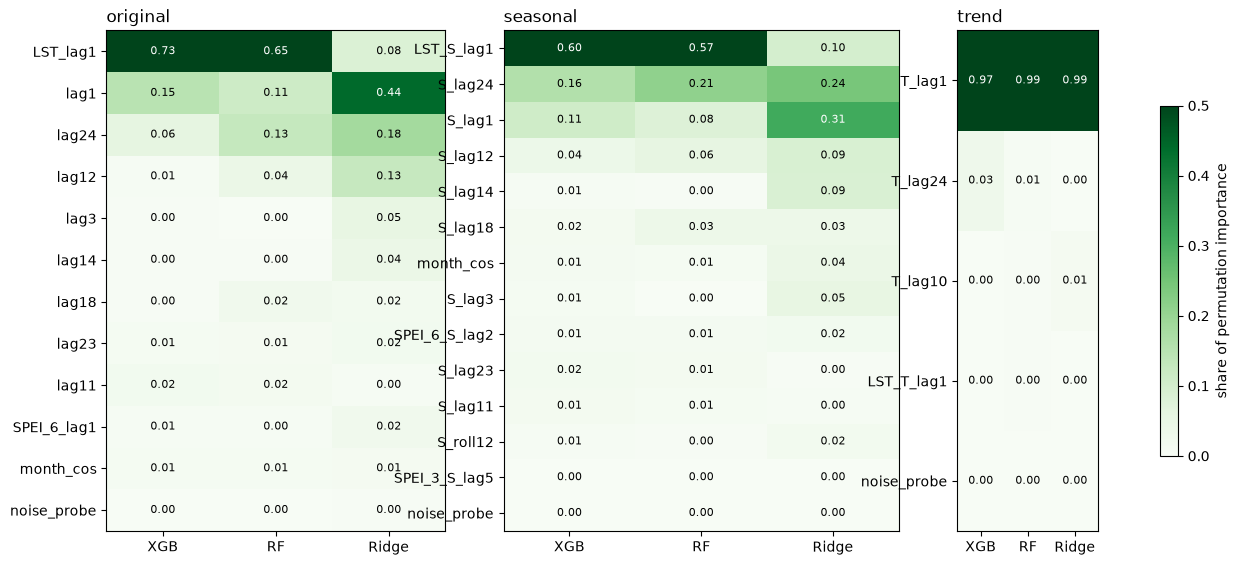

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6.5),
                         gridspec_kw={"width_ratios": [12, 14, 5]})
for ax, b in zip(axes, BRANCHES):
    t = perm_mean[b].unstack("model")[MODEL_NAMES].clip(lower=0)
    t = t / t.sum()
    t = t.loc[t.mean(axis=1).sort_values(ascending=False).index]
    im = ax.imshow(t.to_numpy(), cmap="Greens", vmin=0, vmax=0.5, aspect="auto")
    ax.set_xticks(range(3), ["XGB", "RF", "Ridge"])
    ax.set_yticks(range(len(t)), [f.replace("NDVI_", "").replace("NDVI", "") for f in t.index])
    for i in range(t.shape[0]):
        for j in range(3):
            ax.text(j, i, f"{t.iat[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if t.iat[i, j] > 0.3 else "black")
    ax.set_title(b, loc="left")
fig.colorbar(im, ax=axes, shrink=0.7, label="share of permutation importance")
fig.savefig("../figures/05_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving

In [11]:
perm.to_csv("../results/05_permutation_by_seed.csv")
pd.concat([perm_mean, drop, shap_mean], axis=1).to_csv("../results/05_importance.csv")
agreement.to_csv("../results/05_agreement.csv", index=False)
probes.to_csv("../results/05_probes.csv", index=False)
shares.to_csv("../results/05_family_shares.csv")
print("saved")

saved
